Neste notebook estarei implementando um deep autoencoder na base Cifar10.

In [1]:
from torchvision import datasets
import torch
import torchvision.transforms as T
from torch import nn, optim
import matplotlib.pyplot as plt

torch.manual_seed(123)

Definição do dataset:

In [3]:
dataset_train = datasets.CIFAR10('../', train = True, download = True, transform = T.ToTensor())
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

dataset_test = datasets.CIFAR10('../', train = False, download = True, transform = T.ToTensor())
loader_test = torch.utils.data.DataLoader(dataset_test, batch_size = 128, shuffle = True)

100%|██████████| 170M/170M [00:09<00:00, 18.8MB/s] 


In [62]:
# 784 -> 128 -> 64 -> 32 -> 64 -> 128 -> 784

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(nn.Flatten(),
                                   
                                   # Codificador
                                   # Imagem de entrada: 32 x 32 com 3 canais (RGB)
                                   nn.Linear(32 * 32 * 3, 500),
                                   nn.ReLU(),
                                   nn.Linear(500, 250),
                                   nn.ReLU(),
                                   nn.Linear(250, 125),
                                   nn.ReLU(),

                                   # Decodificador
                                   nn.Linear(125, 250),
                                   nn.ReLU(),
                                   nn.Linear(250, 500),
                                   nn.ReLU(),
                                   nn.Linear(500, 32 * 32 * 3),
                                   nn.Sigmoid())
    def forward(self, X):
        return self.model(X)
    

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [65]:
model = Autoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

Treinamento do modelo junto com o teste em cada epoch:

In [66]:
for epoch in range(100):
    # Treinamento
    total_loss_train = 0.0
    model.train()

    for inputs, _ in loader_train:
        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        targets = inputs.view(*outputs.shape)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
    
    # Teste
    total_loss_val = 0.0
    model.eval()

    with torch.no_grad():
        for inputs, _ in loader_test:
            inputs = inputs.to(device)
            outputs = model(inputs)

            targets = inputs.view(*outputs.shape)
            loss = criterion(outputs, targets)
            
            total_loss_val += loss.item()
        
    # Final da época
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(epoch + 1, total_loss_train/len(loader_train), total_loss_val/len(loader_test)))

ÉPOCA   1: perda_train 0.62660 perda_val 0.60970
ÉPOCA   2: perda_train 0.60502 perda_val 0.60319
ÉPOCA   3: perda_train 0.60117 perda_val 0.60175
ÉPOCA   4: perda_train 0.59649 perda_val 0.59555
ÉPOCA   5: perda_train 0.59257 perda_val 0.59463
ÉPOCA   6: perda_train 0.58936 perda_val 0.58947
ÉPOCA   7: perda_train 0.58802 perda_val 0.58814
ÉPOCA   8: perda_train 0.58659 perda_val 0.58753
ÉPOCA   9: perda_train 0.58568 perda_val 0.58660
ÉPOCA  10: perda_train 0.58436 perda_val 0.58482
ÉPOCA  11: perda_train 0.58303 perda_val 0.58338
ÉPOCA  12: perda_train 0.58189 perda_val 0.58219
ÉPOCA  13: perda_train 0.58118 perda_val 0.58127
ÉPOCA  14: perda_train 0.58069 perda_val 0.58213
ÉPOCA  15: perda_train 0.58021 perda_val 0.58173
ÉPOCA  16: perda_train 0.57987 perda_val 0.58109
ÉPOCA  17: perda_train 0.57937 perda_val 0.58011
ÉPOCA  18: perda_train 0.57880 perda_val 0.57928
ÉPOCA  19: perda_train 0.57818 perda_val 0.57858
ÉPOCA  20: perda_train 0.57753 perda_val 0.57846
ÉPOCA  21: perda_tra

Criação do encoder com base no autoencoder:

In [67]:
list(model.children())[0]

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=500, bias=True)
  (2): ReLU()
  (3): Linear(in_features=500, out_features=250, bias=True)
  (4): ReLU()
  (5): Linear(in_features=250, out_features=125, bias=True)
  (6): ReLU()
  (7): Linear(in_features=125, out_features=250, bias=True)
  (8): ReLU()
  (9): Linear(in_features=250, out_features=500, bias=True)
  (10): ReLU()
  (11): Linear(in_features=500, out_features=3072, bias=True)
  (12): Sigmoid()
)

In [68]:
class Encoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        # Apenas camadas de 0 a 7 do Autoencoder.
        self.model = nn.Sequential(*list(autoencoder.children())[0][:7])

    def forward(self, X):
        return self.model(X)
    
encoder = Encoder(model).to(device)

Criação do decoder com base no autoencoder:

In [69]:
class Decoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        # Apenas camadas de 7 a 12 do Autoencoder.
        self.model = nn.Sequential(*list(autoencoder.children())[0][7:])

    def forward(self, X):
        return self.model(X)

decoder = Decoder(model).to(device)

Visualização dos resultados

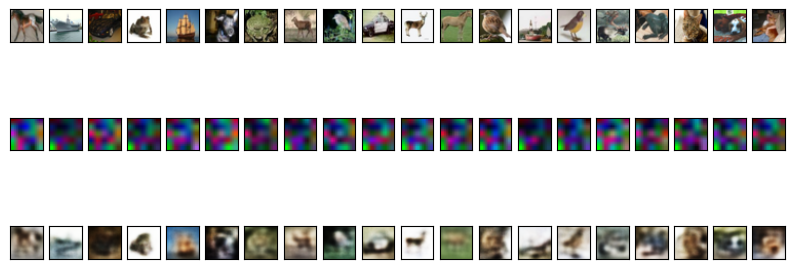

In [73]:
import torch.nn.functional as F

numero_imagens = 20
# Pega 20 imagens do batch 0
imagens_teste = (next(iter(loader_test))[0][:numero_imagens]).to(device)

encoder.eval()
imagens_codificadas = encoder(imagens_teste)

decoder.eval()
imagens_decodificadas = decoder(imagens_codificadas)

# CIFAR10 e saida do decoder sao RGB: (N, 3, 32, 32) -> (N, 32, 32, 3)
imagens_teste_plt = imagens_teste.detach().cpu().permute(0, 2, 3, 1).numpy()

# Visualiza o codigo (125) como 5x5x5 e reescala para 16x16 RGB
latent = imagens_codificadas.detach().cpu().reshape(-1, 5, 5, 5).permute(0, 3, 1, 2)
latent_rgb = latent[:, :3, :, :].float()
flat = latent_rgb.reshape(latent_rgb.size(0), -1)
min_v = flat.min(dim = 1).values.view(-1, 1, 1, 1)
max_v = flat.max(dim = 1).values.view(-1, 1, 1, 1)
latent_rgb = (latent_rgb - min_v) / (max_v - min_v + 1e-8)
latent_rgb = F.interpolate(latent_rgb, size = (16, 16), mode = 'bilinear', align_corners = False)
imagens_codificadas_plt = latent_rgb.permute(0, 2, 3, 1).numpy()

imagens_decodificadas_plt = imagens_decodificadas.view(-1, 3, 32, 32).detach().cpu().clamp(0, 1).permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for row_idx, (imagens, ax_row) in enumerate(zip([imagens_teste_plt, imagens_codificadas_plt, imagens_decodificadas_plt], axes)):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img.clip(0, 1))
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)